In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np


In [2]:
dataset = pd.read_csv("../datasets/cgpa_package.csv")
dataset.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


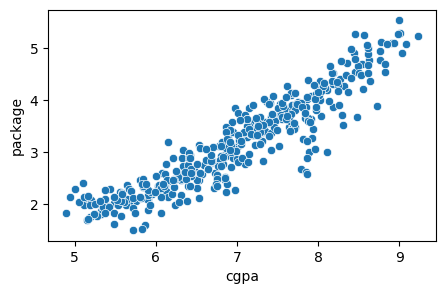

In [ ]:
plt.figure(figsize=(5,3))
sns.scatterplot(x="cgpa",y="package",data=dataset)
plt.show()

In [4]:
dataset.isnull().sum()

cgpa       0
package    0
dtype: int64

In [5]:
x = dataset[["cgpa"]]
y = dataset["package"]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
lr = LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
lr.coef_

array([0.82523687])

In [9]:
lr.intercept_

np.float64(-2.6008343898004376)

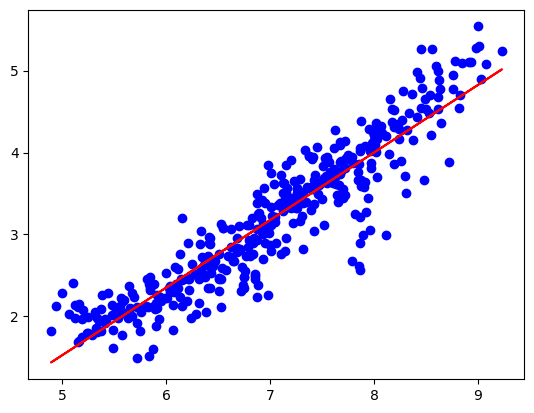

In [10]:
plt.scatter(x, y, color='blue')  # original points

# Regression line
y_pred = lr.coef_[0] * x + lr.intercept_
plt.plot(x, y_pred, color='red')  # line
plt.show()

In [11]:
lr.score(x_test,y_test)*100

85.79606813451383

In [12]:
lr.predict([[6.89]])

c:\Users\HP\Desktop\Projects\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.08504763])

In [13]:
lr.coef_*6.89+lr.intercept_

array([3.08504763])

In [14]:
y_prd = lr.predict(x)

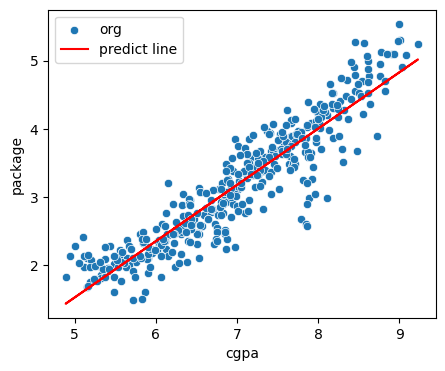

In [15]:
plt.figure(figsize=(5,4))
sns.scatterplot(x="cgpa",y="package",data=dataset)
plt.plot(dataset["cgpa"],y_prd,c="red")
plt.legend(["org","predict line"])
plt.show()